In [1]:
!python --version


Python 3.13.11


### Projeto Final Disciplina "Python, Ciência de Dados e Pandas" - 1º Semestre


In [2]:
!pip install pandas

In [3]:
# Importa a biblioteca Pandas, utilizada para leitura, tratamento e análise de dados.
import pandas as pd

# Mostra de onde o Pandas foi carregado no computador.
print(pd)

# Exibe a versão instalada da biblioteca Pandas.
print(pd.__version__)


<module 'pandas' from 'C:\\Users\\henri\\anaconda3\\envs\\fema-si\\Lib\\site-packages\\pandas\\__init__.py'>
2.3.3


In [4]:
# Configura a exibição máxima de linhas
pd.set_option('display.max_rows', 100)

# Exibe todas as colunas do DataFrame
pd.set_option('display.max_columns', None)

# Remove limite de largura da visualização
pd.set_option('display.width', None)

# Exibe todo o conteúdo das colunas de texto
pd.set_option('display.max_colwidth', None)

#### Download automático do arquivo .csv (Sample Superstore)

A célula abaixo realiza o download automático do arquivo `superstore.csv` (Sample - Superstore),
utilizando a biblioteca `urllib.request`, da mesma forma trabalhada em sala de aula.


In [5]:
# Importa o módulo urllib.request, utilizado para baixar arquivos da internet
import urllib.request

# Endereço (URL) do arquivo .csv "Sample - Superstore"
url_csv = 'https://raw.githubusercontent.com/sumit0072/Superstore-Data-Analysis/main/Sample%20-%20Superstore.csv'

# Realiza o download do arquivo e salva localmente como 'superstore.csv'
urllib.request.urlretrieve(url_csv, 'superstore.csv')


('superstore.csv', <http.client.HTTPMessage at 0x19c6daaefd0>)

In [6]:
# Lê o arquivo CSV 'superstore.csv' e cria o DataFrame df.
# sep=',' informa que as colunas do CSV são separadas por vírgula.
# encoding='iso-8859-1' define a codificação dos caracteres do arquivo.
df = pd.read_csv('superstore.csv', sep = ',', encoding = 'iso-8859-1')


In [7]:
# Exporta o DataFrame para um novo arquivo CSV.
# Isso pode ser usado para salvar uma cópia dos dados ou um dataset tratado.
df.to_csv('superstore_copia.csv', index=False)

In [8]:
df.shape

(9994, 21)

In [9]:
df.columns


Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [10]:
# A função shape retorna a quantidade de linhas e colunas do DataFrame.
# df.shape[0] representa o número de linhas.
# df.shape[1] representa o número de colunas.
print('Quantidade de Linhas e Colunas: ', df.shape)
print(df.shape[0], 'linhas')
print(df.shape[1], 'colunas')


Quantidade de Linhas e Colunas:  (9994, 21)
9994 linhas
21 colunas


In [51]:
# A Função df.info() mostra um resumo geral do DataFrame, parecido com uma "ficha técnica" do df:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

#### Tratamento de dados faltantes

A análise de `df.isna().sum()` mostra que o dataset não possui valores
faltantes (missing) em nenhuma coluna. Ainda assim, mantemos a célula de
tratamento da coluna `Postal Code` como boa prática, garantindo que, caso
existam valores nulos, eles sejam preenchidos com `0` (`fillna`).


In [50]:
df.isna().sum()


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Ano              0
Mes              0
AnoMes           0
dtype: int64

In [14]:
# Exibe o tipo de dado de cada coluna do DataFrame
# Isso ajuda a identificar colunas numéricas, textos e datas
df.dtypes


Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [15]:
# Tratando Dados Faltantes
# Valores ausentes foram preenchidos para evitar erros nas análises posteriores
df['Postal Code'] = df['Postal Code'].fillna(0)

#### Análise exploratória: contagens, ordenações e filtros

A partir daqui exploramos o dataset com `value_counts`, `sort_values`,
`nlargest`, `nsmallest` e `query`, identificando categorias mais vendidas,
estados com mais pedidos, maiores e menores vendas, além de filtros por
categoria e por valor de venda.


In [16]:
# Quantidade de vendas por categoria
df['Category'].value_counts()


Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

In [17]:
# Estados com maior número de pedidos
df['State'].value_counts()


State
California              2001
New York                1128
Texas                    985
Pennsylvania             587
Washington               506
Illinois                 492
Ohio                     469
Florida                  383
Michigan                 255
North Carolina           249
Arizona                  224
Virginia                 224
Georgia                  184
Tennessee                183
Colorado                 182
Indiana                  149
Kentucky                 139
Massachusetts            135
New Jersey               130
Oregon                   124
Wisconsin                110
Maryland                 105
Delaware                  96
Minnesota                 89
Connecticut               82
Missouri                  66
Oklahoma                  66
Alabama                   61
Arkansas                  60
Rhode Island              56
Utah                      53
Mississippi               53
South Carolina            42
Louisiana                 42
Nevada  

In [18]:
# As maiores vendas realizadas
df.sort_values(by='Sales', ascending=False)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
2697,2698,CA-2014-145317,3/18/2014,3/23/2014,Standard Class,SM-20320,Sean Miller,Home Office,United States,Jacksonville,Florida,32216,South,TEC-MA-10002412,Technology,Machines,Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,6,0.5,-1811.0784
6826,6827,CA-2016-118689,10/2/2016,10/9/2016,Standard Class,TC-20980,Tamara Chand,Corporate,United States,Lafayette,Indiana,47905,Central,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,17499.950,5,0.0,8399.9760
8153,8154,CA-2017-140151,3/23/2017,3/25/2017,First Class,RB-19360,Raymond Buch,Consumer,United States,Seattle,Washington,98115,West,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,13999.960,4,0.0,6719.9808
2623,2624,CA-2017-127180,10/22/2017,10/24/2017,First Class,TA-21385,Tom Ashbrook,Home Office,United States,New York City,New York,10024,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,11199.968,4,0.2,3919.9888
4190,4191,CA-2017-166709,11/17/2017,11/22/2017,Standard Class,HL-15040,Hunter Lopez,Consumer,United States,Newark,Delaware,19711,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,10499.970,3,0.0,5039.9856
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,2107,US-2014-152723,9/26/2014,9/26/2014,Same Day,HG-14965,Henry Goldwyn,Corporate,United States,Mesquite,Texas,75150,Central,OFF-BI-10003460,Office Supplies,Binders,Acco 3-Hole Punch,0.876,1,0.8,-1.4016
4711,4712,CA-2014-112403,3/31/2014,3/31/2014,Same Day,JO-15280,Jas O'Carroll,Consumer,United States,Philadelphia,Pennsylvania,19120,East,OFF-BI-10003529,Office Supplies,Binders,Avery Round Ring Poly Binders,0.852,1,0.7,-0.5964
8658,8659,CA-2016-168361,6/21/2016,6/25/2016,Standard Class,KB-16600,Ken Brennan,Corporate,United States,Chicago,Illinois,60623,Central,OFF-BI-10003727,Office Supplies,Binders,Avery Durable Slant Ring Binders With Label Holder,0.836,1,0.8,-1.3376
9292,9293,CA-2017-124114,3/2/2017,3/2/2017,Same Day,RS-19765,Roland Schwarz,Corporate,United States,Waco,Texas,76706,Central,OFF-BI-10004022,Office Supplies,Binders,Acco Suede Grain Vinyl Round Ring Binder,0.556,1,0.8,-0.9452


In [19]:
# Top 10 maiores vendas
df.nlargest(10, 'Sales')

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
2697,2698,CA-2014-145317,3/18/2014,3/23/2014,Standard Class,SM-20320,Sean Miller,Home Office,United States,Jacksonville,Florida,32216,South,TEC-MA-10002412,Technology,Machines,Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,6,0.5,-1811.0784
6826,6827,CA-2016-118689,10/2/2016,10/9/2016,Standard Class,TC-20980,Tamara Chand,Corporate,United States,Lafayette,Indiana,47905,Central,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,17499.950,5,0.0,8399.9760
8153,8154,CA-2017-140151,3/23/2017,3/25/2017,First Class,RB-19360,Raymond Buch,Consumer,United States,Seattle,Washington,98115,West,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,13999.960,4,0.0,6719.9808
2623,2624,CA-2017-127180,10/22/2017,10/24/2017,First Class,TA-21385,Tom Ashbrook,Home Office,United States,New York City,New York,10024,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,11199.968,4,0.2,3919.9888
4190,4191,CA-2017-166709,11/17/2017,11/22/2017,Standard Class,HL-15040,Hunter Lopez,Consumer,United States,Newark,Delaware,19711,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,10499.970,3,0.0,5039.9856
9039,9040,CA-2016-117121,12/17/2016,12/21/2016,Standard Class,AB-10105,Adrian Barton,Consumer,United States,Detroit,Michigan,48205,Central,OFF-BI-10000545,Office Supplies,Binders,GBC Ibimaster 500 Manual ProClick Binding System,9892.740,13,0.0,4946.3700
4098,4099,CA-2014-116904,9/23/2014,9/28/2014,Standard Class,SC-20095,Sanjit Chand,Consumer,United States,Minneapolis,Minnesota,55407,Central,OFF-BI-10001120,Office Supplies,Binders,Ibico EPK-21 Electric Binding System,9449.950,5,0.0,4630.4755
4277,4278,US-2016-107440,4/16/2016,4/20/2016,Standard Class,BS-11365,Bill Shonely,Corporate,United States,Lakewood,New Jersey,8701,East,TEC-MA-10001047,Technology,Machines,"3D Systems Cube Printer, 2nd Generation, Magenta",9099.930,7,0.0,2365.9818
8488,8489,CA-2016-158841,2/2/2016,2/4/2016,Second Class,SE-20110,Sanjit Engle,Consumer,United States,Arlington,Virginia,22204,South,TEC-MA-10001127,Technology,Machines,"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",8749.950,5,0.0,2799.9840
6425,6426,CA-2016-143714,5/23/2016,5/27/2016,Standard Class,CC-12370,Christopher Conant,Consumer,United States,Philadelphia,Pennsylvania,19120,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,8399.976,4,0.4,1119.9968


In [20]:
# Menores vendas registradas
df.nsmallest(10, 'Sales')

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
4101,4102,US-2017-102288,6/19/2017,6/23/2017,Standard Class,ZC-21910,Zuschuss Carroll,Consumer,United States,Houston,Texas,77095,Central,OFF-AP-10002906,Office Supplies,Appliances,Hoover Replacement Belt for Commercial Guardsman Heavy-Duty Upright Vacuum,0.444,1,0.8,-1.1100
9292,9293,CA-2017-124114,3/2/2017,3/2/2017,Same Day,RS-19765,Roland Schwarz,Corporate,United States,Waco,Texas,76706,Central,OFF-BI-10004022,Office Supplies,Binders,Acco Suede Grain Vinyl Round Ring Binder,0.556,1,0.8,-0.9452
8658,8659,CA-2016-168361,6/21/2016,6/25/2016,Standard Class,KB-16600,Ken Brennan,Corporate,United States,Chicago,Illinois,60623,Central,OFF-BI-10003727,Office Supplies,Binders,Avery Durable Slant Ring Binders With Label Holder,0.836,1,0.8,-1.3376
4711,4712,CA-2014-112403,3/31/2014,3/31/2014,Same Day,JO-15280,Jas O'Carroll,Consumer,United States,Philadelphia,Pennsylvania,19120,East,OFF-BI-10003529,Office Supplies,Binders,Avery Round Ring Poly Binders,0.852,1,0.7,-0.5964
2106,2107,US-2014-152723,9/26/2014,9/26/2014,Same Day,HG-14965,Henry Goldwyn,Corporate,United States,Mesquite,Texas,75150,Central,OFF-BI-10003460,Office Supplies,Binders,Acco 3-Hole Punch,0.876,1,0.8,-1.4016
7548,7549,CA-2014-103492,10/10/2014,10/15/2014,Standard Class,CM-12715,Craig Molinari,Corporate,United States,Huntsville,Texas,77340,Central,OFF-BI-10004140,Office Supplies,Binders,Avery Non-Stick Binders,0.898,1,0.8,-1.5715
8033,8034,CA-2015-119690,6/25/2015,6/28/2015,First Class,MV-17485,Mark Van Huff,Consumer,United States,Houston,Texas,77041,Central,OFF-BI-10000201,Office Supplies,Binders,"Avery Triangle Shaped Sheet Lifters, Black, 2/Pack",0.984,2,0.8,-1.4760
2761,2762,CA-2017-126536,10/12/2017,10/14/2017,First Class,NK-18490,Neil Knudson,Home Office,United States,San Francisco,California,94110,West,TEC-AC-10003709,Technology,Accessories,Maxell 4.7GB DVD-R 5/Pack,0.990,1,0.0,0.4356
8024,8025,CA-2014-129189,7/21/2014,7/25/2014,Standard Class,HM-14860,Harry Marie,Corporate,United States,Dallas,Texas,75217,Central,OFF-BI-10000494,Office Supplies,Binders,Acco Economy Flexible Poly Round Ring Binder,1.044,1,0.8,-1.8270
976,977,US-2017-100209,7/9/2017,7/15/2017,Standard Class,TD-20995,Tamara Dahlen,Consumer,United States,Portland,Oregon,97206,West,OFF-BI-10002012,Office Supplies,Binders,Wilson Jones Easy Flow II Sheet Lifters,1.080,2,0.7,-0.7920


In [21]:
# Somente vendas da categoria Tecnologia.
df.query("Category == 'Technology'")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
7,8,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.152,6,0.2,90.7152
11,12,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,TEC-PH-10002033,Technology,Phones,Konftel 250 Conference phone - Charcoal black,911.424,4,0.2,68.3568
19,20,CA-2014-143336,8/27/2014,9/1/2014,Second Class,ZD-21925,Zuschuss Donatelli,Consumer,United States,San Francisco,California,94109,West,TEC-PH-10001949,Technology,Phones,Cisco SPA 501G IP Phone,213.480,3,0.2,16.0110
26,27,CA-2016-121755,1/16/2016,1/20/2016,Second Class,EH-13945,Eric Hoffmann,Consumer,United States,Los Angeles,California,90049,West,TEC-AC-10003027,Technology,Accessories,Imation 8GB Mini TravelDrive USB 2.0 Flash Drive,90.570,3,0.0,11.7741
35,36,CA-2016-117590,12/8/2016,12/10/2016,First Class,GH-14485,Gene Hale,Corporate,United States,Richardson,Texas,75080,Central,TEC-PH-10004977,Technology,Phones,GE 30524EE4,1097.544,7,0.2,123.4737
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9983,9984,US-2016-157728,9/22/2016,9/28/2016,Standard Class,RC-19960,Ryan Crowe,Consumer,United States,Grand Rapids,Michigan,49505,Central,TEC-PH-10001305,Technology,Phones,Panasonic KX TS208W Corded phone,97.980,2,0.0,27.4344
9986,9987,CA-2016-125794,9/29/2016,10/3/2016,Standard Class,ML-17410,Maris LaWare,Consumer,United States,Los Angeles,California,90008,West,TEC-AC-10003399,Technology,Accessories,Memorex Mini Travel Drive 64 GB USB 2.0 Flash Drive,36.240,1,0.0,15.2208
9987,9988,CA-2017-163629,11/17/2017,11/21/2017,Standard Class,RA-19885,Ruben Ausman,Corporate,United States,Athens,Georgia,30605,South,TEC-AC-10001539,Technology,Accessories,Logitech G430 Surround Sound Gaming Headset with Dolby 7.1 Technology,79.990,1,0.0,28.7964
9988,9989,CA-2017-163629,11/17/2017,11/21/2017,Standard Class,RA-19885,Ruben Ausman,Corporate,United States,Athens,Georgia,30605,South,TEC-PH-10004006,Technology,Phones,Panasonic KX - TS880B Telephone,206.100,5,0.0,55.6470


In [22]:
# Vendas acima de mil dólares
df.query("Sales > 1000")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
10,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.184,9,0.2,85.3092
24,25,CA-2015-106320,9/25/2015,9/30/2015,Standard Class,EB-13870,Emily Burns,Consumer,United States,Orem,Utah,84057,West,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,1044.630,3,0.0,240.2649
27,28,US-2015-150630,9/17/2015,9/21/2015,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,Pennsylvania,19140,East,FUR-BO-10004834,Furniture,Bookcases,"Riverside Palais Royal Lawyers Bookcase, Royale Cherry Finish",3083.430,7,0.5,-1665.0522
35,36,CA-2016-117590,12/8/2016,12/10/2016,First Class,GH-14485,Gene Hale,Corporate,United States,Richardson,Texas,75080,Central,TEC-PH-10004977,Technology,Phones,GE 30524EE4,1097.544,7,0.2,123.4737
54,55,CA-2016-105816,12/11/2016,12/17/2016,Standard Class,JM-15265,Janet Molinari,Corporate,United States,New York City,New York,10024,East,TEC-PH-10002447,Technology,Phones,AT&T CL83451 4-Handset Telephone,1029.950,5,0.0,298.6855
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9866,9867,US-2015-116981,3/26/2015,3/28/2015,Second Class,SM-20950,Suzanne McNair,Corporate,United States,New York City,New York,10009,East,OFF-ST-10002615,Office Supplies,Storage,"Dual Level, Single-Width Filing Carts",1085.420,7,0.0,282.2092
9925,9926,CA-2015-159534,3/20/2015,3/23/2015,First Class,DH-13075,Dave Hallsten,Corporate,United States,New York City,New York,10035,East,OFF-BI-10003656,Office Supplies,Binders,Fellowes PB200 Plastic Comb Binding Machine,1087.936,8,0.2,353.5792
9929,9930,CA-2016-129630,9/4/2016,9/4/2016,Same Day,IM-15055,Ionia McGrath,Consumer,United States,San Francisco,California,94122,West,TEC-CO-10003763,Technology,Copiers,Canon PC1060 Personal Laser Copier,2799.960,5,0.2,944.9865
9947,9948,CA-2017-121559,6/1/2017,6/3/2017,Second Class,HW-14935,Helen Wasserman,Corporate,United States,Indianapolis,Indiana,46203,Central,FUR-CH-10003746,Furniture,Chairs,Hon 4070 Series Pagoda Round Back Stacking Chairs,1925.880,6,0.0,539.2464


#### Conversão de datas e extração de Ano/Mês

As colunas `Order Date` e `Ship Date` estão como `object` (texto), no formato
mês/dia/ano (padrão dos EUA). Utilizamos `pd.to_datetime` para convertê-las
para o tipo `datetime`, permitindo extrair `Ano`, `Mes` e o período `AnoMes`
(`to_period('M')`) através das propriedades `.dt`.


In [23]:
# Converte a coluna Order Date para o tipo datetime
# Neste dataset as datas estão no formato mês/dia/ano (padrão dos EUA)
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Converte a coluna Ship Date para o tipo datetime
df['Ship Date'] = pd.to_datetime(df['Ship Date'])


In [24]:
# Extrai o ano da venda
df['Ano'] = df['Order Date'].dt.year

# Extrai o mês da venda
df['Mes'] = df['Order Date'].dt.month

df[['Order Date', 'Ano', 'Mes']].head()

,Order Date,Ano,Mes
0,2016-11-08,2016,11
1,2016-11-08,2016,11
2,2016-06-12,2016,6
3,2015-10-11,2015,10
4,2015-10-11,2015,10


In [25]:
# # Extrai o ano da venda
df['Ano'] = df['Order Date'].dt.year

In [26]:
# Quantidade de pedidos por ano.
df['Ano'].value_counts()

Ano
2017    3312
2016    2587
2015    2102
2014    1993
Name: count, dtype: int64

In [27]:
# Soma o valor das vendas por ano
vendas_mes = df.groupby('Ano')['Sales'].sum()

vendas_mes

Ano
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64

In [28]:
# Cria uma coluna contendo apenas o período Ano-Mês da venda
df['AnoMes'] = df['Order Date'].dt.to_period('M')

df[['Order Date', 'AnoMes']].head()

,Order Date,AnoMes
0,2016-11-08,2016-11
1,2016-11-08,2016-11
2,2016-06-12,2016-06
3,2015-10-11,2015-10
4,2015-10-11,2015-10


#### Análises numéricas sobre a série mensal de vendas

Com a série `vendas_mes` (soma de `Sales` por `AnoMes`), aplicamos:
- `diff()` para a variação absoluta entre meses;
- `pct_change()` para a variação percentual entre meses;
- `cumsum()` para o acumulado de vendas ao longo do tempo;
- `rolling(3).mean()` e `rolling(3).sum()` para média e soma móvel
  considerando os últimos 3 meses.


In [29]:
# Soma o valor das vendas por mês
vendas_mes = df.groupby('AnoMes')['Sales'].sum()

vendas_mes

AnoMes
2014-01     14236.8950
2014-02      4519.8920
2014-03     55691.0090
2014-04     28295.3450
2014-05     23648.2870
2014-06     34595.1276
2014-07     33946.3930
2014-08     27909.4685
2014-09     81777.3508
2014-10     31453.3930
2014-11     78628.7167
2014-12     69545.6205
2015-01     18174.0756
2015-02     11951.4110
2015-03     38726.2520
2015-04     34195.2085
2015-05     30131.6865
2015-06     24797.2920
2015-07     28765.3250
2015-08     36898.3322
2015-09     64595.9180
2015-10     31404.9235
2015-11     75972.5635
2015-12     74919.5212
2016-01     18542.4910
2016-02     22978.8150
2016-03     51715.8750
2016-04     38750.0390
2016-05     56987.7280
2016-06     40344.5340
2016-07     39261.9630
2016-08     31115.3743
2016-09     73410.0249
2016-10     59687.7450
2016-11     79411.9658
2016-12     96999.0430
2017-01     43971.3740
2017-02     20301.1334
2017-03     58872.3528
2017-04     36521.5361
2017-05     44261.1102
2017-06     52981.7257
2017-07     45264.4160
2017

In [30]:
# Calcula a diferença de vendas entre um mês e o mês anterior
vendas_mes.diff()

AnoMes
2014-01           NaN
2014-02    -9717.0030
2014-03    51171.1170
2014-04   -27395.6640
2014-05    -4647.0580
2014-06    10946.8406
2014-07     -648.7346
2014-08    -6036.9245
2014-09    53867.8823
2014-10   -50323.9578
2014-11    47175.3237
2014-12    -9083.0962
2015-01   -51371.5449
2015-02    -6222.6646
2015-03    26774.8410
2015-04    -4531.0435
2015-05    -4063.5220
2015-06    -5334.3945
2015-07     3968.0330
2015-08     8133.0072
2015-09    27697.5858
2015-10   -33190.9945
2015-11    44567.6400
2015-12    -1053.0423
2016-01   -56377.0302
2016-02     4436.3240
2016-03    28737.0600
2016-04   -12965.8360
2016-05    18237.6890
2016-06   -16643.1940
2016-07    -1082.5710
2016-08    -8146.5887
2016-09    42294.6506
2016-10   -13722.2799
2016-11    19724.2208
2016-12    17587.0772
2017-01   -53027.6690
2017-02   -23670.2406
2017-03    38571.2194
2017-04   -22350.8167
2017-05     7739.5741
2017-06     8720.6155
2017-07    -7717.3097
2017-08    17856.4720
2017-09    24745.7640
201

In [31]:
# Calcula a variação percentual das vendas em relação ao mês anterior
vendas_mes.pct_change()

AnoMes
2014-01          NaN
2014-02    -0.682523
2014-03    11.321314
2014-04    -0.491923
2014-05    -0.164234
2014-06     0.462902
2014-07    -0.018752
2014-08    -0.177837
2014-09     1.930093
2014-10    -0.615378
2014-11     1.499848
2014-12    -0.115519
2015-01    -0.738674
2015-02    -0.342392
2015-03     2.240308
2015-04    -0.117002
2015-05    -0.118833
2015-06    -0.177036
2015-07     0.160019
2015-08     0.282736
2015-09     0.750646
2015-10    -0.513825
2015-11     1.419129
2015-12    -0.013861
2016-01    -0.752501
2016-02     0.239252
2016-03     1.250589
2016-04    -0.250713
2016-05     0.470650
2016-06    -0.292049
2016-07    -0.026833
2016-08    -0.207493
2016-09     1.359285
2016-10    -0.186927
2016-11     0.330457
2016-12     0.221466
2017-01    -0.546682
2017-02    -0.538310
2017-03     1.899954
2017-04    -0.379649
2017-05     0.211918
2017-06     0.197027
2017-07    -0.145660
2017-08     0.394492
2017-09     0.392038
2017-10    -0.114830
2017-11     0.522917
2017-1

In [32]:
# Calcula o acumulado de vendas ao longo do tempo
vendas_mes.cumsum()

AnoMes
2014-01    1.423690e+04
2014-02    1.875679e+04
2014-03    7.444780e+04
2014-04    1.027431e+05
2014-05    1.263914e+05
2014-06    1.609866e+05
2014-07    1.949329e+05
2014-08    2.228424e+05
2014-09    3.046198e+05
2014-10    3.360732e+05
2014-11    4.147019e+05
2014-12    4.842475e+05
2015-01    5.024216e+05
2015-02    5.143730e+05
2015-03    5.530992e+05
2015-04    5.872944e+05
2015-05    6.174261e+05
2015-06    6.422234e+05
2015-07    6.709887e+05
2015-08    7.078871e+05
2015-09    7.724830e+05
2015-10    8.038879e+05
2015-11    8.798605e+05
2015-12    9.547800e+05
2016-01    9.733225e+05
2016-02    9.963013e+05
2016-03    1.048017e+06
2016-04    1.086767e+06
2016-05    1.143755e+06
2016-06    1.184099e+06
2016-07    1.223361e+06
2016-08    1.254477e+06
2016-09    1.327887e+06
2016-10    1.387575e+06
2016-11    1.466987e+06
2016-12    1.563986e+06
2017-01    1.607957e+06
2017-02    1.628258e+06
2017-03    1.687130e+06
2017-04    1.723652e+06
2017-05    1.767913e+06
2017-06  

In [33]:
# Calcula a média móvel das vendas considerando os últimos 3 meses
vendas_mes.rolling(3).mean()

AnoMes
2014-01             NaN
2014-02             NaN
2014-03    24815.932000
2014-04    29502.082000
2014-05    35878.213667
2014-06    28846.253200
2014-07    30729.935867
2014-08    32150.329700
2014-09    47877.737433
2014-10    47046.737433
2014-11    63953.153500
2014-12    59875.910067
2015-01    55449.470933
2015-02    33223.702367
2015-03    22950.579533
2015-04    28290.957167
2015-05    34351.049000
2015-06    29708.062333
2015-07    27898.101167
2015-08    30153.649733
2015-09    43419.858400
2015-10    44299.724567
2015-11    57324.468333
2015-12    60765.669400
2016-01    56478.191900
2016-02    38813.609067
2016-03    31079.060333
2016-04    37814.909667
2016-05    49151.214000
2016-06    45360.767000
2016-07    45531.408333
2016-08    36907.290433
2016-09    47929.120733
2016-10    54737.714733
2016-11    70836.578567
2016-12    78699.584600
2017-01    73460.794267
2017-02    53757.183467
2017-03    41048.286733
2017-04    38565.007433
2017-05    46551.666367
2017-06  

In [34]:
# Calcula a soma móvel das vendas considerando os últimos 3 meses
vendas_mes.rolling(3).sum()

AnoMes
2014-01            NaN
2014-02            NaN
2014-03     74447.7960
2014-04     88506.2460
2014-05    107634.6410
2014-06     86538.7596
2014-07     92189.8076
2014-08     96450.9891
2014-09    143633.2123
2014-10    141140.2123
2014-11    191859.4605
2014-12    179627.7302
2015-01    166348.4128
2015-02     99671.1071
2015-03     68851.7386
2015-04     84872.8715
2015-05    103053.1470
2015-06     89124.1870
2015-07     83694.3035
2015-08     90460.9492
2015-09    130259.5752
2015-10    132899.1737
2015-11    171973.4050
2015-12    182297.0082
2016-01    169434.5757
2016-02    116440.8272
2016-03     93237.1810
2016-04    113444.7290
2016-05    147453.6420
2016-06    136082.3010
2016-07    136594.2250
2016-08    110721.8713
2016-09    143787.3622
2016-10    164213.1442
2016-11    212509.7357
2016-12    236098.7538
2017-01    220382.3828
2017-02    161271.5504
2017-03    123144.8602
2017-04    115695.0223
2017-05    139654.9991
2017-06    133764.3720
2017-07    142507.2519
2017

#### Tabela cruzada (crosstab) entre Região e Categoria

Utilizamos `pd.crosstab` para cruzar as colunas `Region` e `Category`,
contando quantos pedidos existem para cada combinação. Em seguida, aplicamos
`transpose()` (inverter linhas e colunas) e `stack()` (empilhar os dados em
uma única coluna), exatamente como visto no projeto do CENIPA.


In [35]:
# Cria uma tabela cruzada entre região e categoria.
pd.crosstab(df['Region'], df['Category'])

Category,Furniture,Office Supplies,Technology
Region,,,
Central,481,1422,420
East,601,1712,535
South,332,995,293
West,707,1897,599


In [36]:
# Transpõe linhas e colunas da tabela cruzada.
pd.crosstab(
    df['Region'],
    df['Category']
).transpose()

Region,Central,East,South,West
Category,,,,
Furniture,481,601,332,707
Office Supplies,1422,1712,995,1897
Technology,420,535,293,599


In [37]:
# Empilha os dados da tabela cruzada em uma única coluna.
pd.crosstab(
    df['Region'],
    df['Category']
).stack()

Region   Category       
Central  Furniture           481
         Office Supplies    1422
         Technology          420
East     Furniture           601
         Office Supplies    1712
         Technology          535
South    Furniture           332
         Office Supplies     995
         Technology          293
West     Furniture           707
         Office Supplies    1897
         Technology          599
dtype: int64

#### Visualização de dados em gráficos

Para finalizar, geramos gráficos com `matplotlib` e `seaborn`, deixando a
análise mais intuitiva: total de vendas por categoria, total de vendas por
região, e a evolução das vendas mês a mês (`vendas_mes`).


In [44]:
pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [45]:
# Importa as bibliotecas de visualização gráfica
import matplotlib.pyplot as plt
import seaborn as sns

# Define um estilo visual mais agradável para os gráficos
sns.set_style('whitegrid')


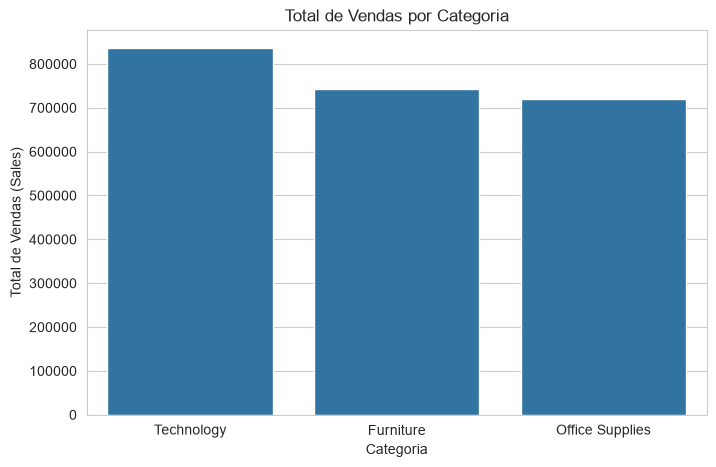

In [46]:
# Soma o total de vendas (Sales) por categoria
vendas_categoria = df.groupby('Category')['Sales'].sum() \
                     .sort_values(ascending=False)

# Gráfico de barras: total de vendas por categoria
plt.figure(figsize=(8, 5))
sns.barplot(x=vendas_categoria.index, y=vendas_categoria.values)
plt.title('Total de Vendas por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Total de Vendas (Sales)')
plt.show()


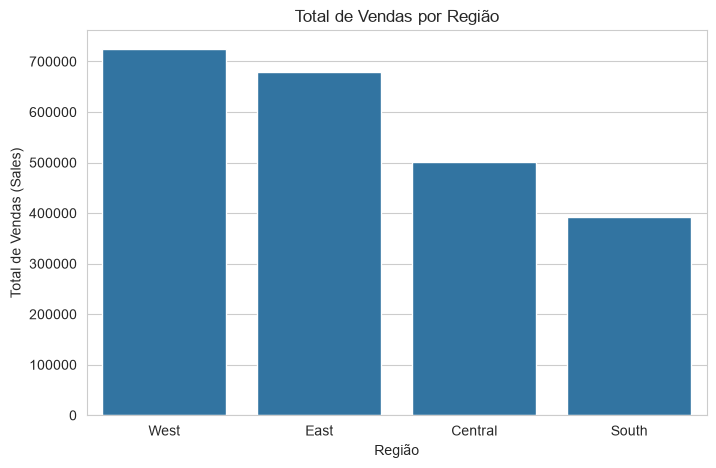

In [47]:
# Soma o total de vendas (Sales) por região
vendas_regiao = df.groupby('Region')['Sales'].sum() \
                  .sort_values(ascending=False)

# Gráfico de barras: total de vendas por região
plt.figure(figsize=(8, 5))
sns.barplot(x=vendas_regiao.index, y=vendas_regiao.values)
plt.title('Total de Vendas por Região')
plt.xlabel('Região')
plt.ylabel('Total de Vendas (Sales)')
plt.show()


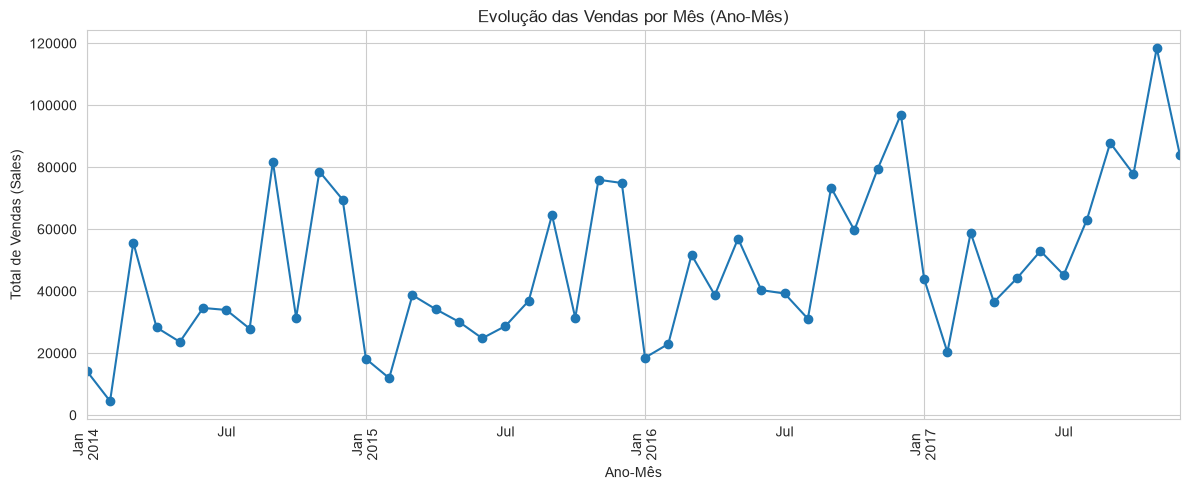

In [48]:
# Gráfico de linha: evolução das vendas mês a mês (vendas_mes)
plt.figure(figsize=(12, 5))
vendas_mes.plot(kind='line', marker='o')
plt.title('Evolução das Vendas por Mês (Ano-Mês)')
plt.xlabel('Ano-Mês')
plt.ylabel('Total de Vendas (Sales)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()